In [37]:
import pandas as pd
import numpy as np
from utils import plot
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_ccf
from arch.unitroot import VarianceRatio

In [61]:
def memory_diagnostics(x, lags=40, alpha=0.05, verbose=True):
    x = np.asarray(x).astype(float)
    x = x[np.isfinite(x)]
    n = len(x)

    plot_acf(x, lags=lags)
    plot_acf(x**2, lags=lags)

    # Stationarity
    adf_stat, adf_p, *_ = adfuller(x, autolag='AIC')
    try:
        kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')
    except:
        kpss_p = np.nan  # fallback if KPSS fails (short data)

    # Autocorrelation (Ljung–Box)
    lb_df = acorr_ljungbox(x, lags=[lags], return_df=True)
    lb_p = lb_df['lb_pvalue'].iloc[0]

    # Volatility clustering (ARCH LM)
    arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)

    # Nonlinearity (Variance Ratio test as proxy)
    try:
        vr_p = VarianceRatio(x).pvalue
    except:
        vr_p = np.nan

    # Simple predictability (AR(1))
    try:
        ar1_fit = AutoReg(x, lags=1).fit()
        ar1_r2 = ar1_fit.rsquared
    except:
        ar1_r2 = np.nan

    # Summary
    results = {
        'n_obs': n,
        'ADF_p': adf_p,
        'KPSS_p': kpss_p,
        'LjungBox_p': lb_p,
        'ARCH_p': arch_p,
        'VR_p': vr_p,
        'AR1_R2': ar1_r2
    }

    if verbose:
        print("=== MEMORY DIAGNOSTICS ===")
        print(f"n = {n}")
        print(f"ADF p = {adf_p:.3g}  → {'stationary ✅' if adf_p < alpha else 'non-stationary ❌'}")
        print(f"KPSS p = {kpss_p:.3g}  → {'stationary ✅' if kpss_p > alpha else 'non-stationary ❌'}")
        print(f"Ljung–Box (lag {lags}) p = {lb_p:.3g}  → {'autocorrelated ✅' if lb_p < alpha else 'independent ❌'}")
        print(f"ARCH LM p = {arch_p:.3g}  → {'volatility memory ✅' if arch_p < alpha else 'no volatility memory ❌'}")
        print(f"Variance Ratio p = {vr_p:.3g}  → {'nonlinear dep. ✅' if vr_p < alpha else 'no nonlinearity ❌'}")
        print("===========================")

    return results

In [39]:
df = pd.read_csv('wbtc_train_data_expanded.csv')

nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

df_amounts = pd.read_csv('wbtc_token_amounts_data.csv')
total_supply = df_amounts['island_token_balance'].values
stable_token_balance = df_amounts['honey_balance'].values
vol_token_balance = df_amounts['wbtc_balance'].values

total_supply = total_supply[len(vol_token_balance) - len(vol_token_price):]
stable_token_balance = stable_token_balance[len(vol_token_balance) - len(vol_token_price):]
vol_token_balance = vol_token_balance[len(vol_token_balance) - len(vol_token_price):]

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


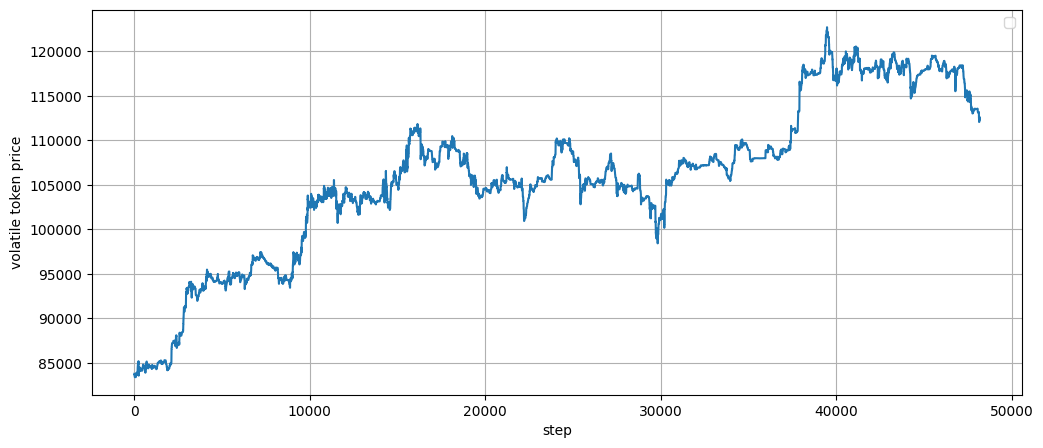

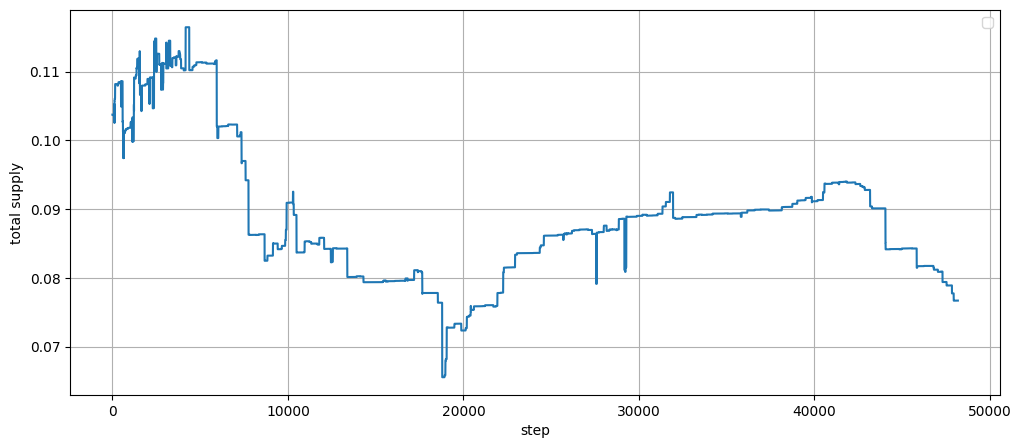

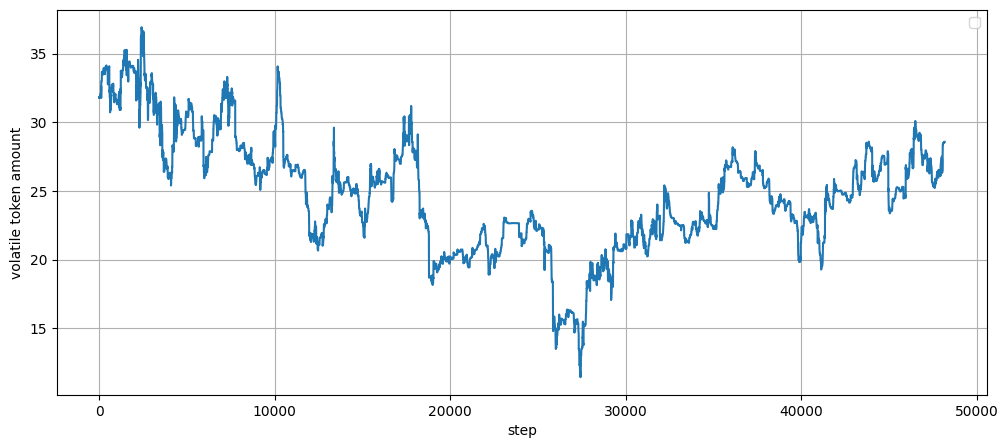

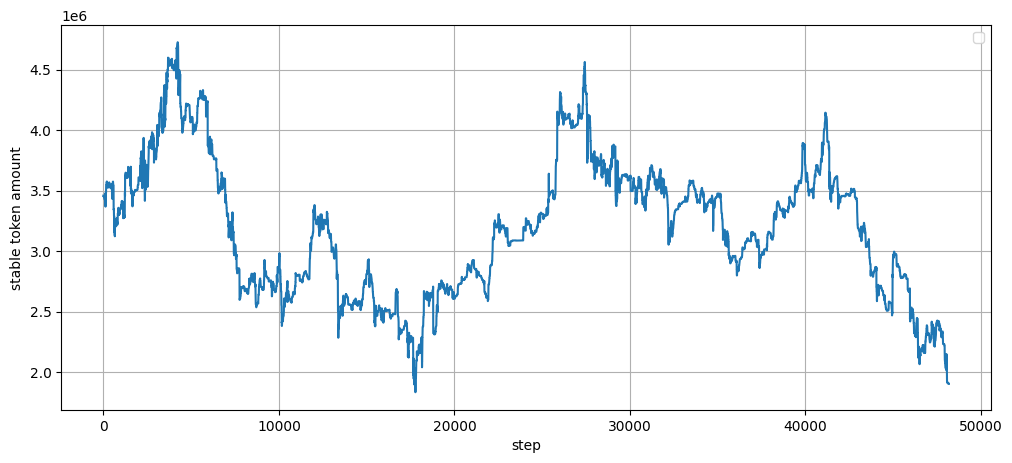

In [40]:
plot(
    [vol_token_price],
    'step',
    'volatile token price'
)

plot(
    [total_supply],
    'step',
    'total supply'
)

plot(
    [vol_token_balance],
    'step',
    'volatile token amount'
)

plot(
    [stable_token_balance],
    'step',
    'stable token amount'
)

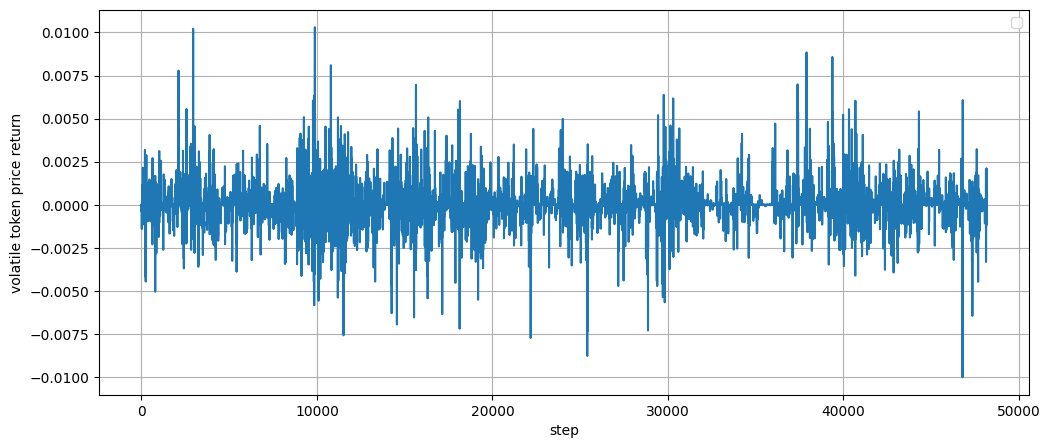

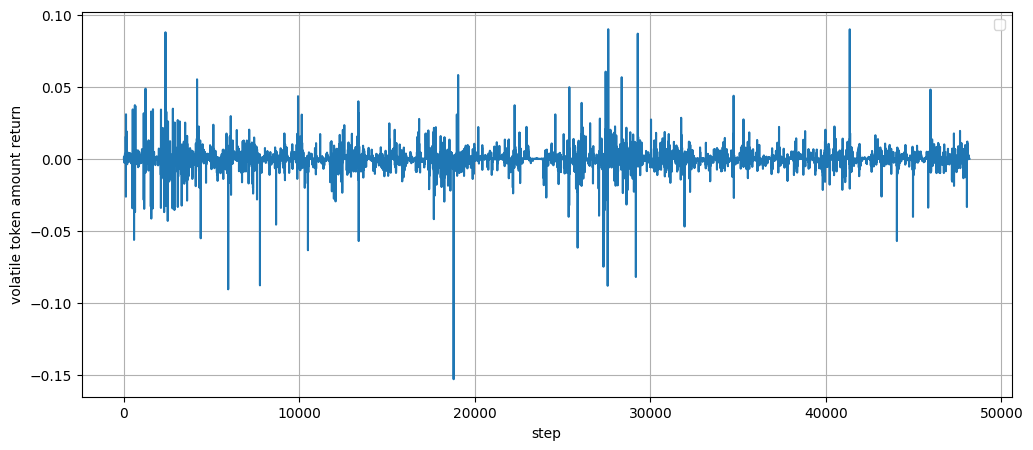

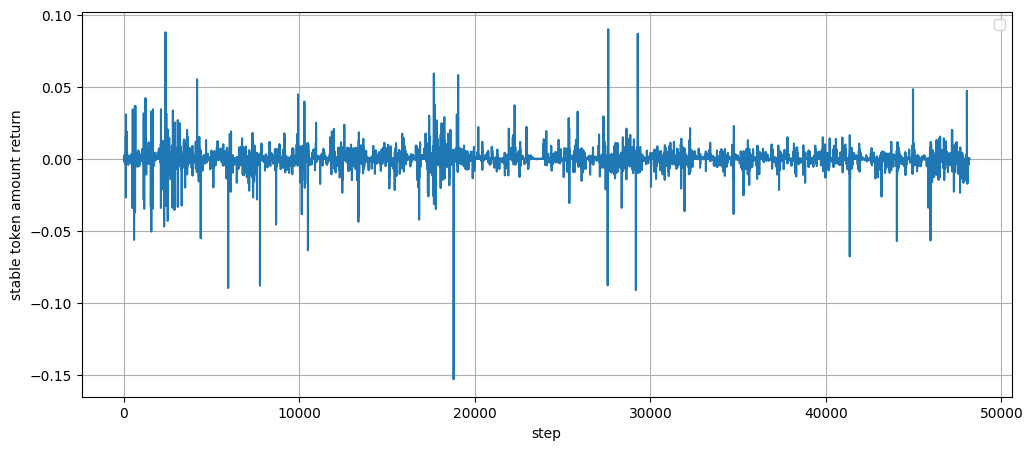

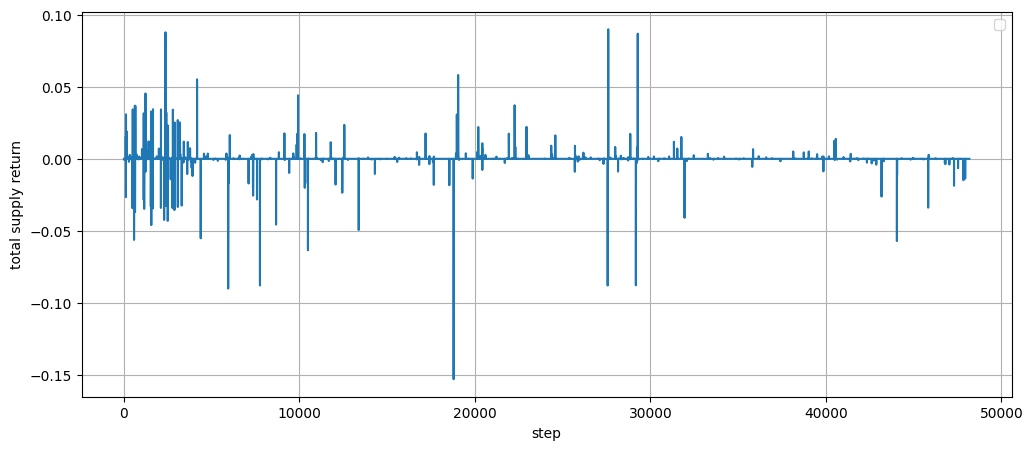

In [41]:
p_r = np.diff(np.log(vol_token_price))
v_r = np.diff(np.log(vol_token_balance))
s_r = np.diff(np.log(stable_token_balance))
ts_r = np.diff(np.log(total_supply))

plot(
    [p_r],
    'step',
    'volatile token price return'
)

plot(
    [v_r],
    'step',
    'volatile token amount return'
)

plot(
    [s_r],
    'step',
    'stable token amount return'
)

plot(
    [ts_r],
    'step',
    'total supply return'
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 48179
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 9.1e-309  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:21: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 48179,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(9.09787147155643e-309),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

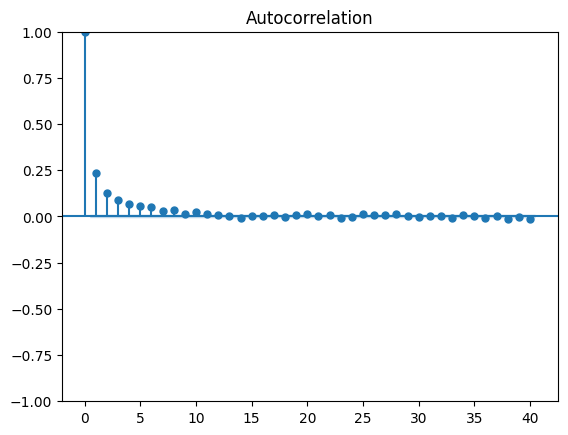

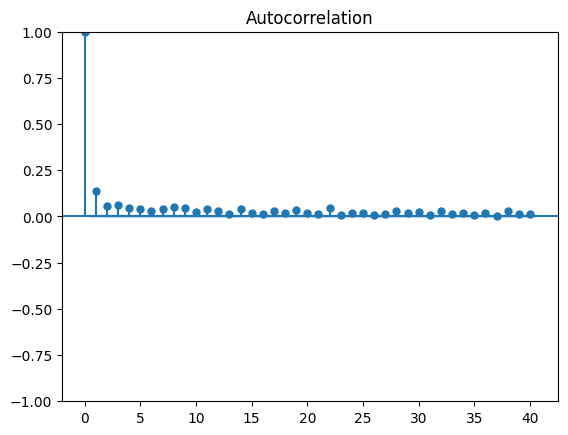

In [62]:
memory_diagnostics(p_r)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 48179
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 0  → autocorrelated ✅
ARCH LM p = 2.57e-22  → volatility memory ✅
Variance Ratio p = 0  → nonlinear dep. ✅


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:21: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 48179,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(0.0),
 'ARCH_p': np.float64(2.5731600863499194e-22),
 'VR_p': np.float64(0.0),
 'AR1_R2': nan}

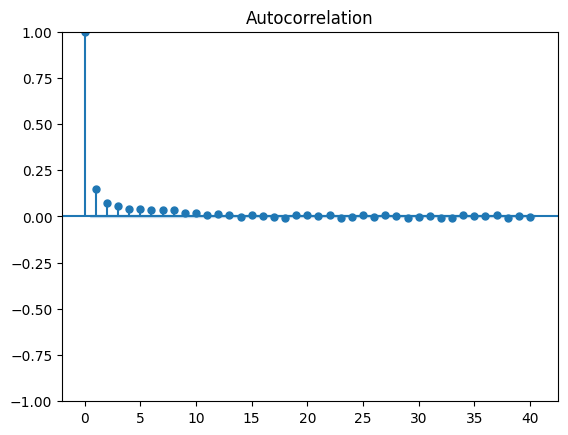

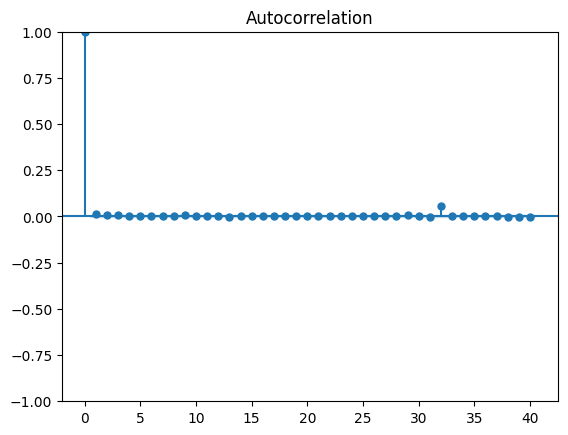

In [63]:
memory_diagnostics(v_r)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 48179
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 7.05e-282  → autocorrelated ✅
ARCH LM p = 1e-13  → volatility memory ✅
Variance Ratio p = 6.66e-15  → nonlinear dep. ✅


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:21: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 48179,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(7.054797469472989e-282),
 'ARCH_p': np.float64(1.0037237980357252e-13),
 'VR_p': np.float64(6.661338147750939e-15),
 'AR1_R2': nan}

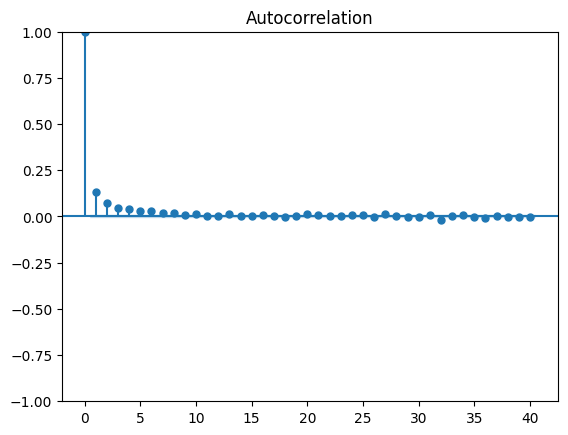

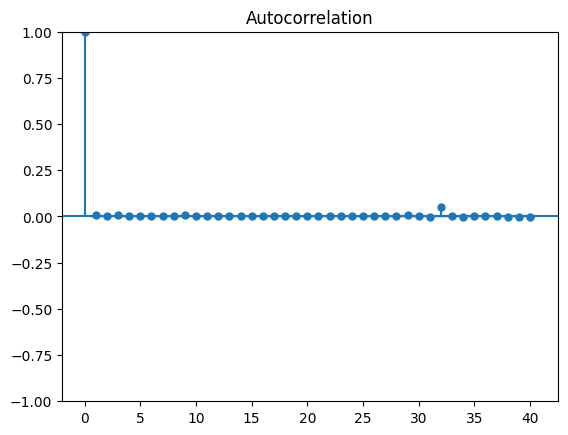

In [64]:
memory_diagnostics(s_r)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression='c', nlags='auto')


=== MEMORY DIAGNOSTICS ===
n = 48179
ADF p = 0  → stationary ✅
KPSS p = 0.1  → stationary ✅
Ljung–Box (lag 40) p = 2.63e-25  → autocorrelated ✅
ARCH LM p = 2.33e-15  → volatility memory ✅
Variance Ratio p = 1.07e-06  → nonlinear dep. ✅


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9664\3907566578.py:21: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_stat, arch_p, *_ = het_arch(x, maxlag=lags)


{'n_obs': 48179,
 'ADF_p': 0.0,
 'KPSS_p': np.float64(0.1),
 'LjungBox_p': np.float64(2.6314666943157556e-25),
 'ARCH_p': np.float64(2.3321675787182267e-15),
 'VR_p': np.float64(1.0713840228326887e-06),
 'AR1_R2': nan}

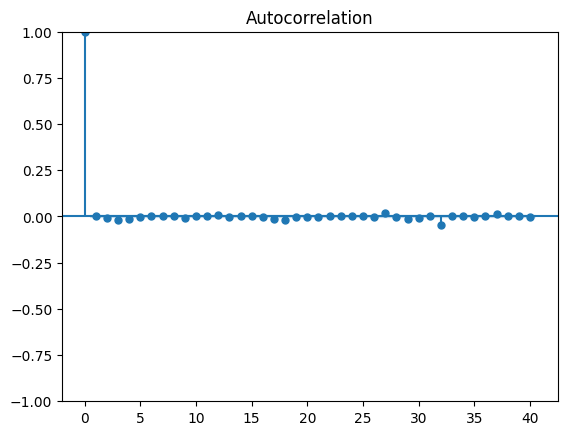

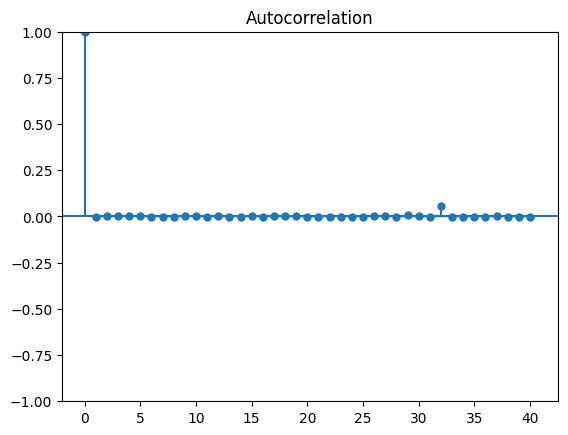

In [65]:
memory_diagnostics(ts_r)

In [46]:
def granger_matrix(data, maxlag=40, verbose=False):
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data, columns=[f"S{i+1}" for i in range(data.shape[1])])
        
    names = data.columns
    pvals = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)
    
    for i in range(len(names)):
        for j in range(len(names)):
            if i == j:
                continue
            test_data = data[[names[i], names[j]]].dropna()
            try:
                res = grangercausalitytests(test_data, maxlag=maxlag, verbose=verbose)
                # take the smallest p-value across all tested lags
                best_p = min(res[lag][0]['ssr_ftest'][1] for lag in res)
                pvals.loc[names[i], names[j]] = best_p
            except Exception as e:
                print(f"Error for {names[j]} → {names[i]}: {e}")
                pvals.loc[names[i], names[j]] = np.nan
                
    return pvals

In [47]:
R = np.column_stack([p_r, v_r, s_r, ts_r])
names = [f"S{i+1}" for i in range(4)]

df = pd.DataFrame(R, columns=names)
pvals = granger_matrix(df, maxlag=5)
print("\n=== Granger Causality p-value Matrix ===")
print(pvals.round(4))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


=== Granger Causality p-value Matrix ===
        S1      S2      S3     S4
S1  1.0000  0.1203  0.0799  0.014
S2  0.7367  1.0000  0.0000  0.000
S3  0.8241  0.0000  1.0000  0.000
S4  0.8786  0.0733  0.0243  1.000


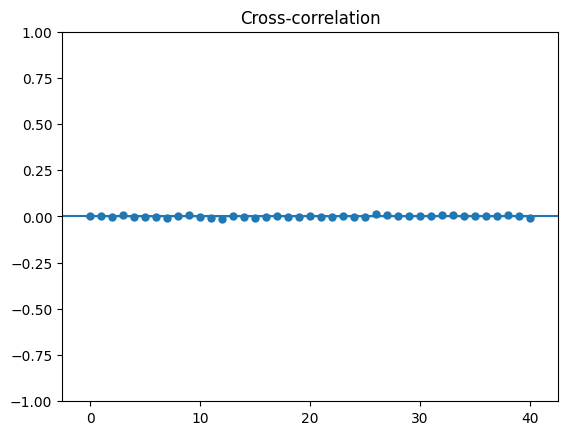

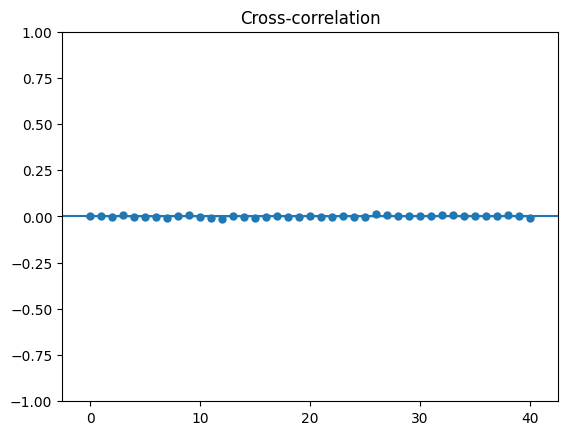

In [48]:
plot_ccf(p_r, v_r, lags=40)

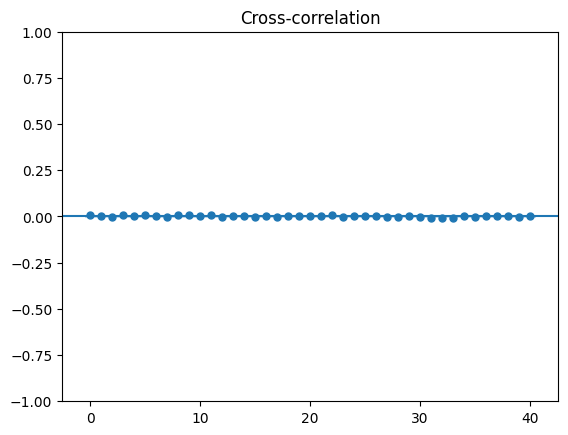

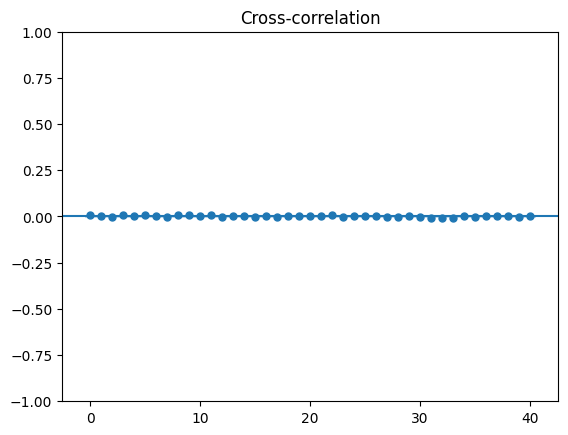

In [49]:
plot_ccf(p_r, s_r, lags=40)

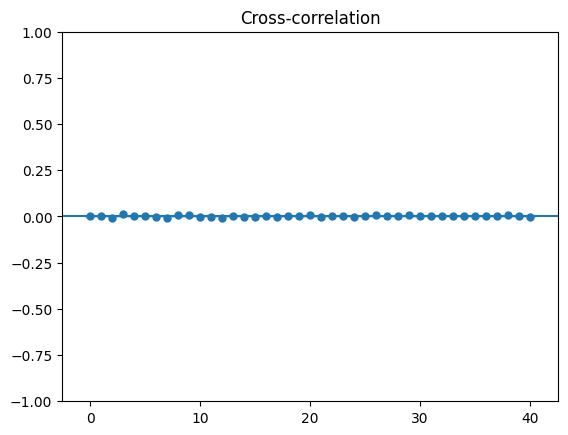

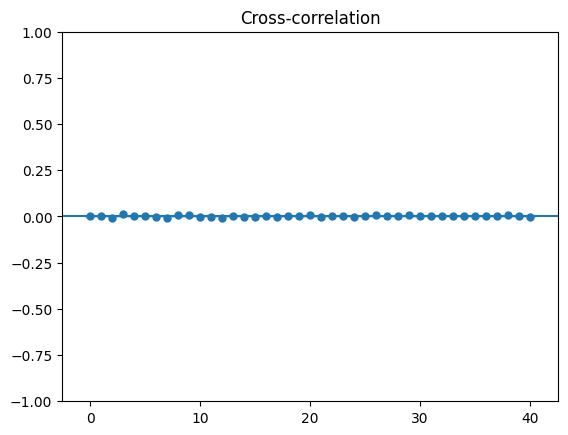

In [50]:
plot_ccf(p_r, ts_r, lags=40)

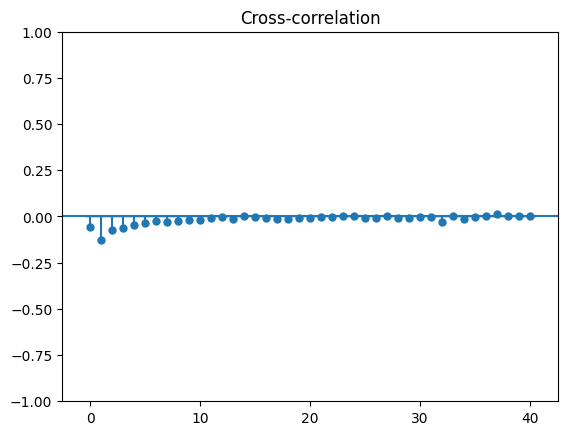

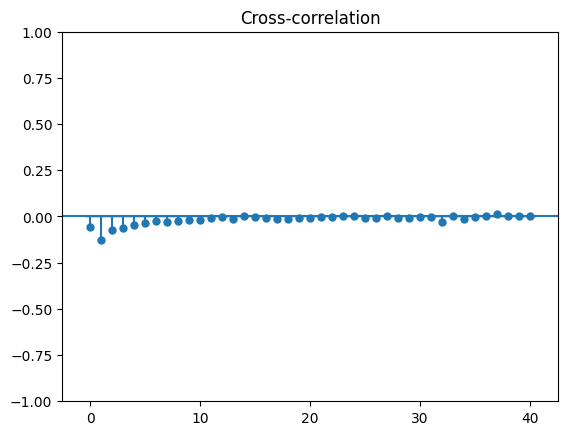

In [51]:
plot_ccf(v_r, s_r, lags=40)

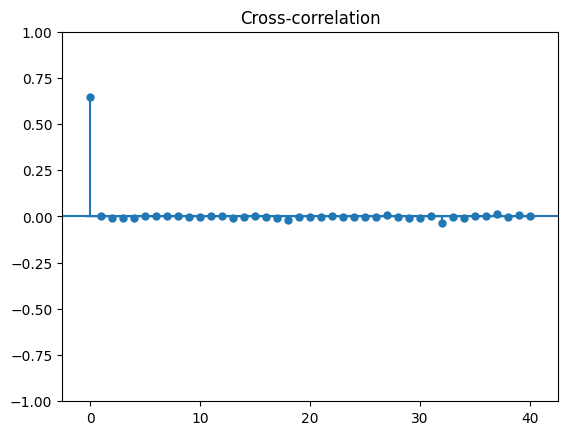

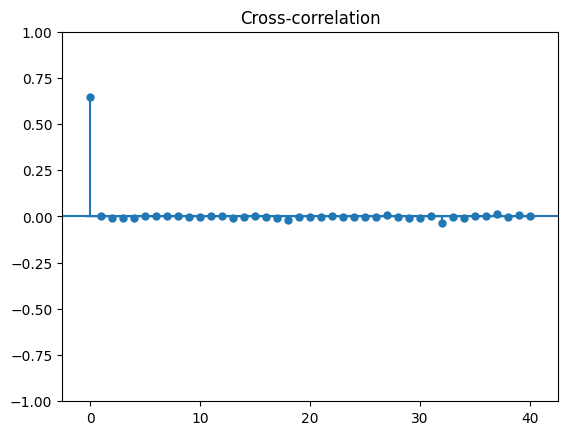

In [52]:
plot_ccf(v_r, ts_r, lags=40)

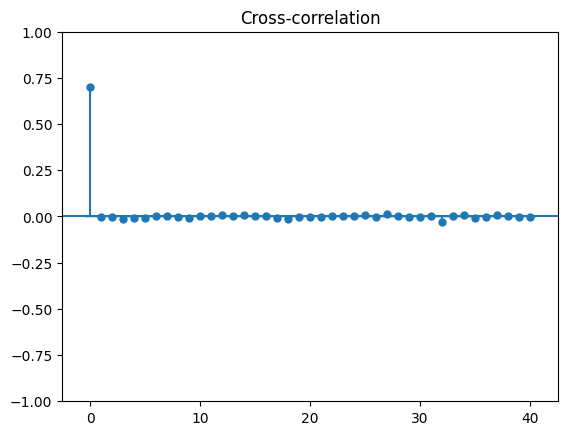

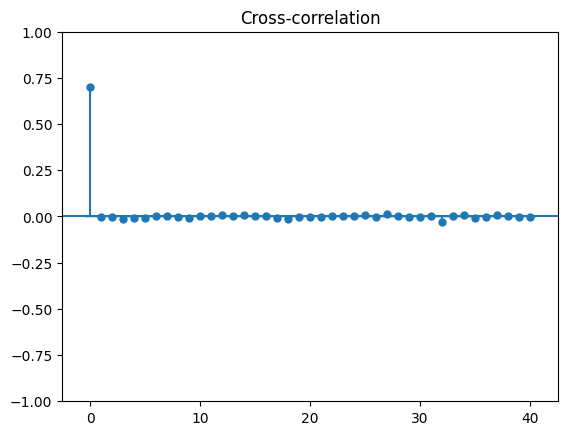

In [53]:
plot_ccf(s_r, ts_r, lags=40)

In [54]:
R = np.column_stack([p_r**2, v_r**2, s_r**2, ts_r**2])
names = [f"S{i+1}" for i in range(4)]

df = pd.DataFrame(R, columns=names)
pvals = granger_matrix(df, maxlag=5)
print("\n=== Granger Causality p-value Matrix ===")
print(pvals.round(4))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


=== Granger Causality p-value Matrix ===
        S1      S2      S3      S4
S1  1.0000  0.2806  0.2887  0.1955
S2  0.5004  1.0000  0.0000  0.0000
S3  0.5467  0.5085  1.0000  0.0000
S4  0.6280  0.5896  0.0911  1.0000


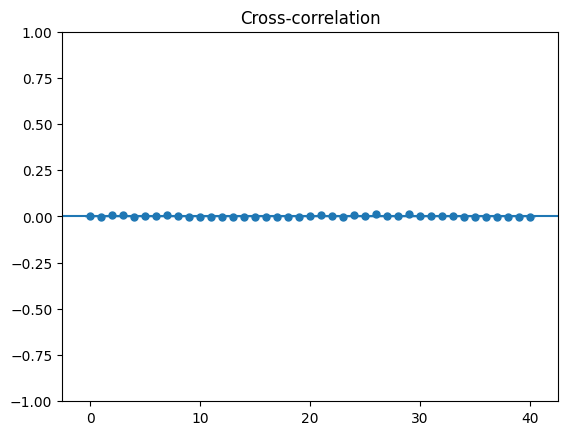

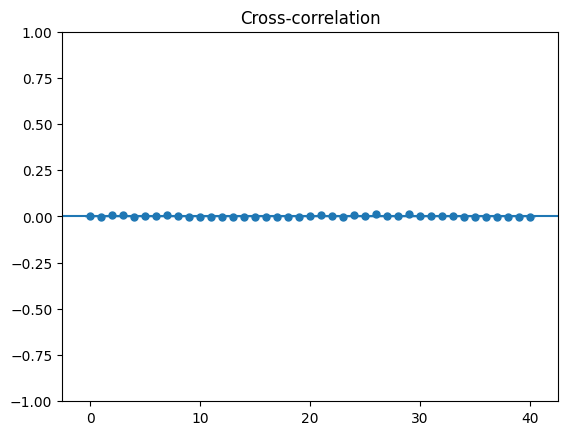

In [55]:
plot_ccf(p_r**2, v_r**2, lags=40)

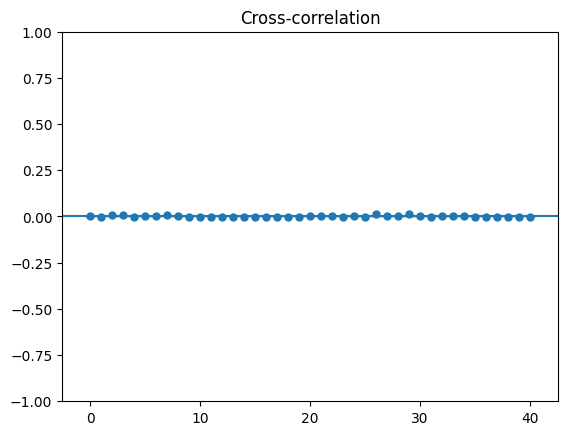

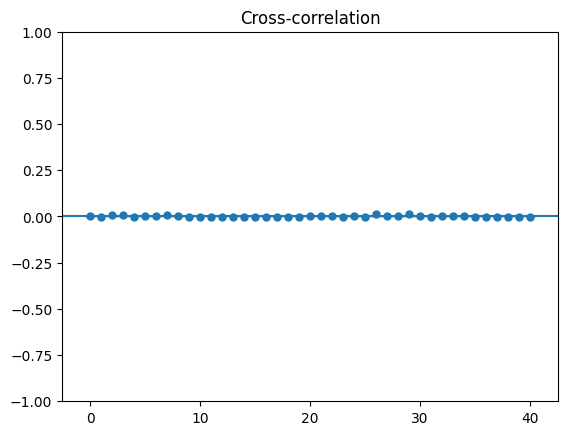

In [56]:
plot_ccf(p_r**2, s_r**2, lags=40)

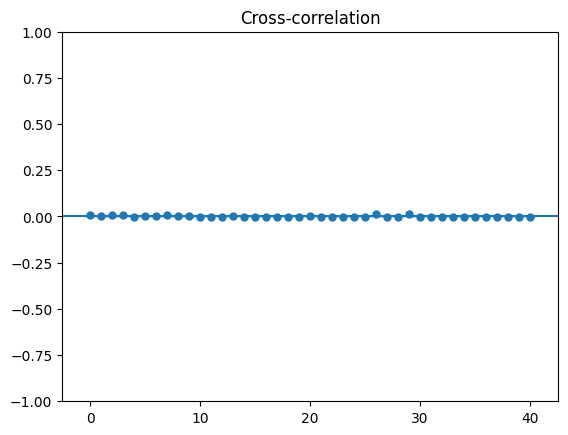

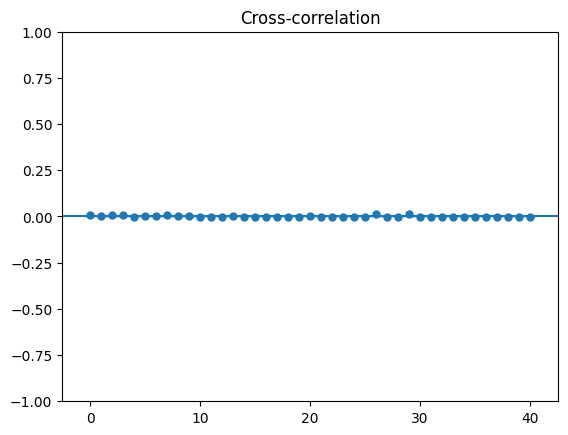

In [57]:
plot_ccf(p_r**2, ts_r**2, lags=40)

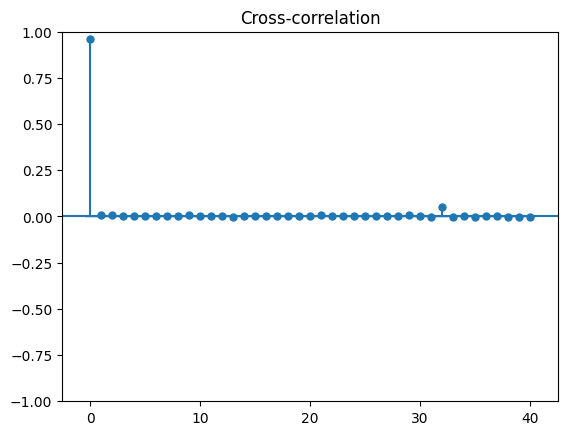

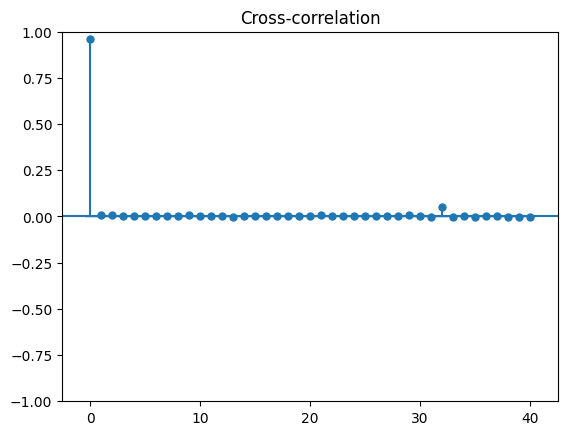

In [58]:
plot_ccf(v_r**2, s_r**2, lags=40)

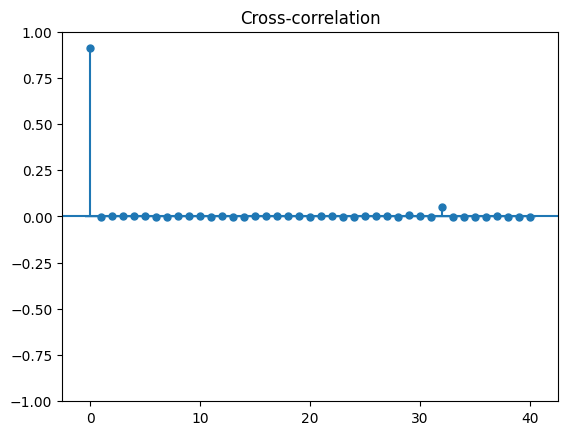

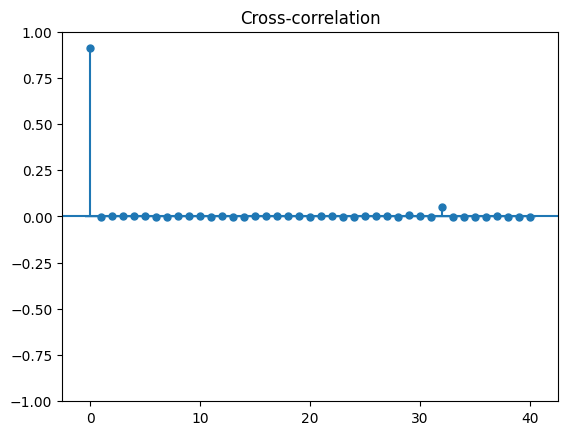

In [59]:
plot_ccf(v_r**2, ts_r**2, lags=40)

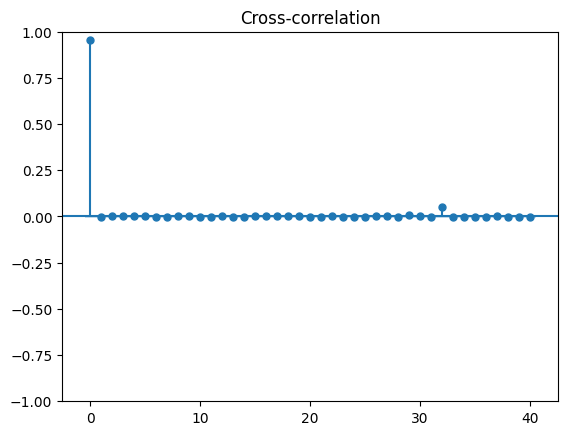

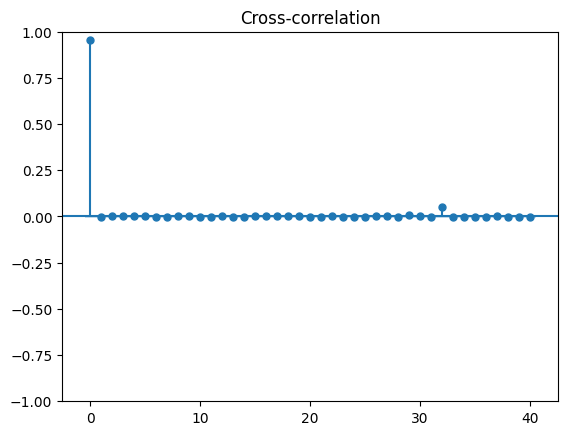

In [60]:
plot_ccf(s_r**2, ts_r**2, lags=40)

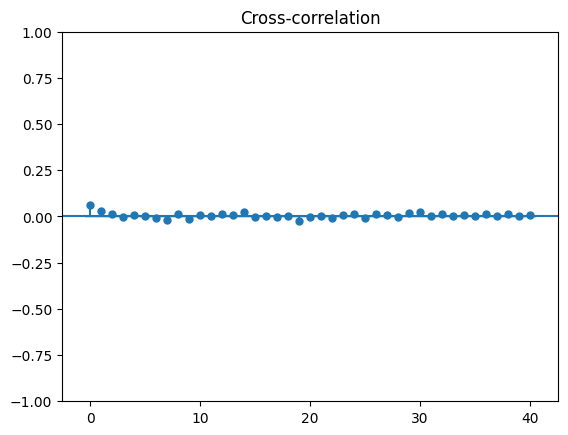

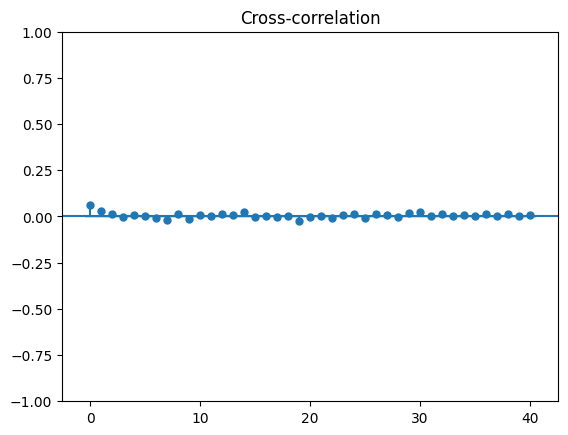

In [67]:
plot_ccf(p_r, p_r**4, lags=40)